In [17]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
print('Libraries loaded ✓')

Libraries loaded ✓


In [18]:
#load dataset
df = pd.read_csv("../data/processed_data/bank-additional-full-processed.csv")
        
df.head(1)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [19]:
df.shape

(41176, 21)

y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64


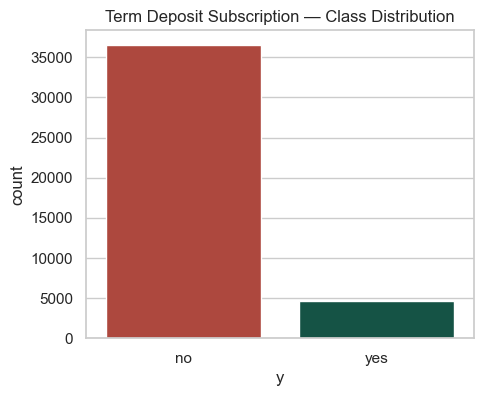

In [20]:
#check Class distribution
print(df['y'].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x='y', data=df, palette=['#c0392b', '#0b5d4a'])
plt.title("Term Deposit Subscription — Class Distribution")

plt.savefig("../reports/class_distribution.png", dpi=150)
plt.show()


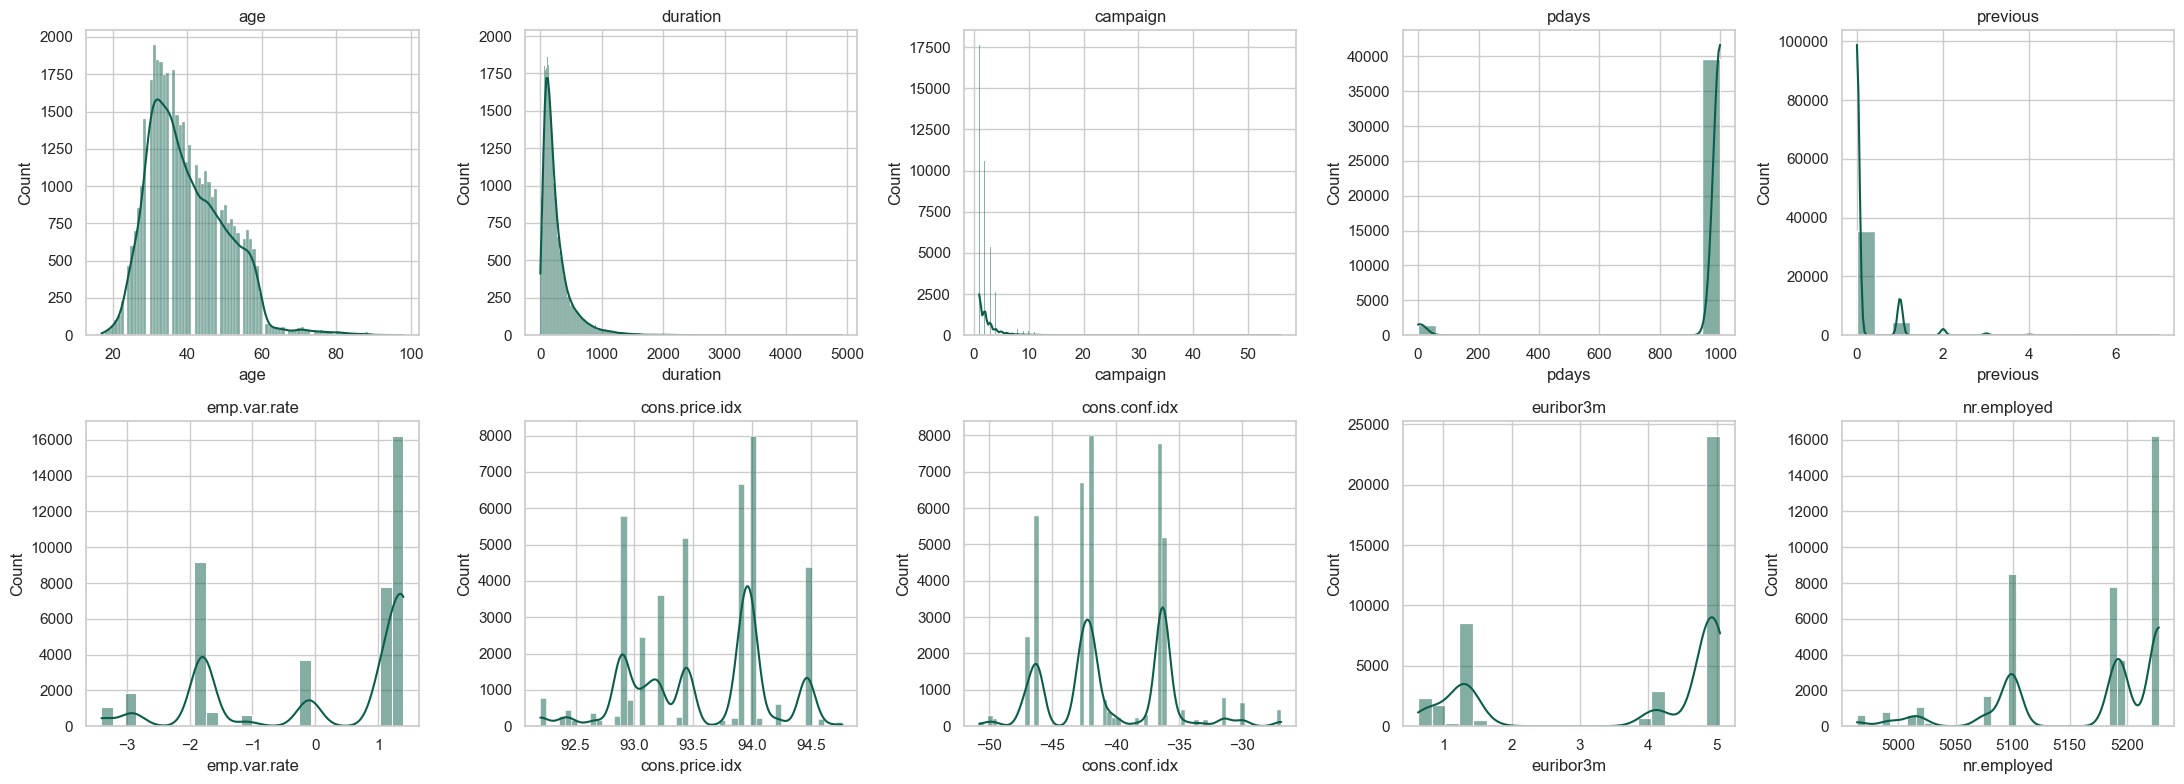

In [21]:
# Check Numeric distribution

num_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#0b5d4a')
    ax.set_title(col)

plt.tight_layout()
plt.savefig("../reports/numeric_distributions.png", dpi=150)
plt.show()

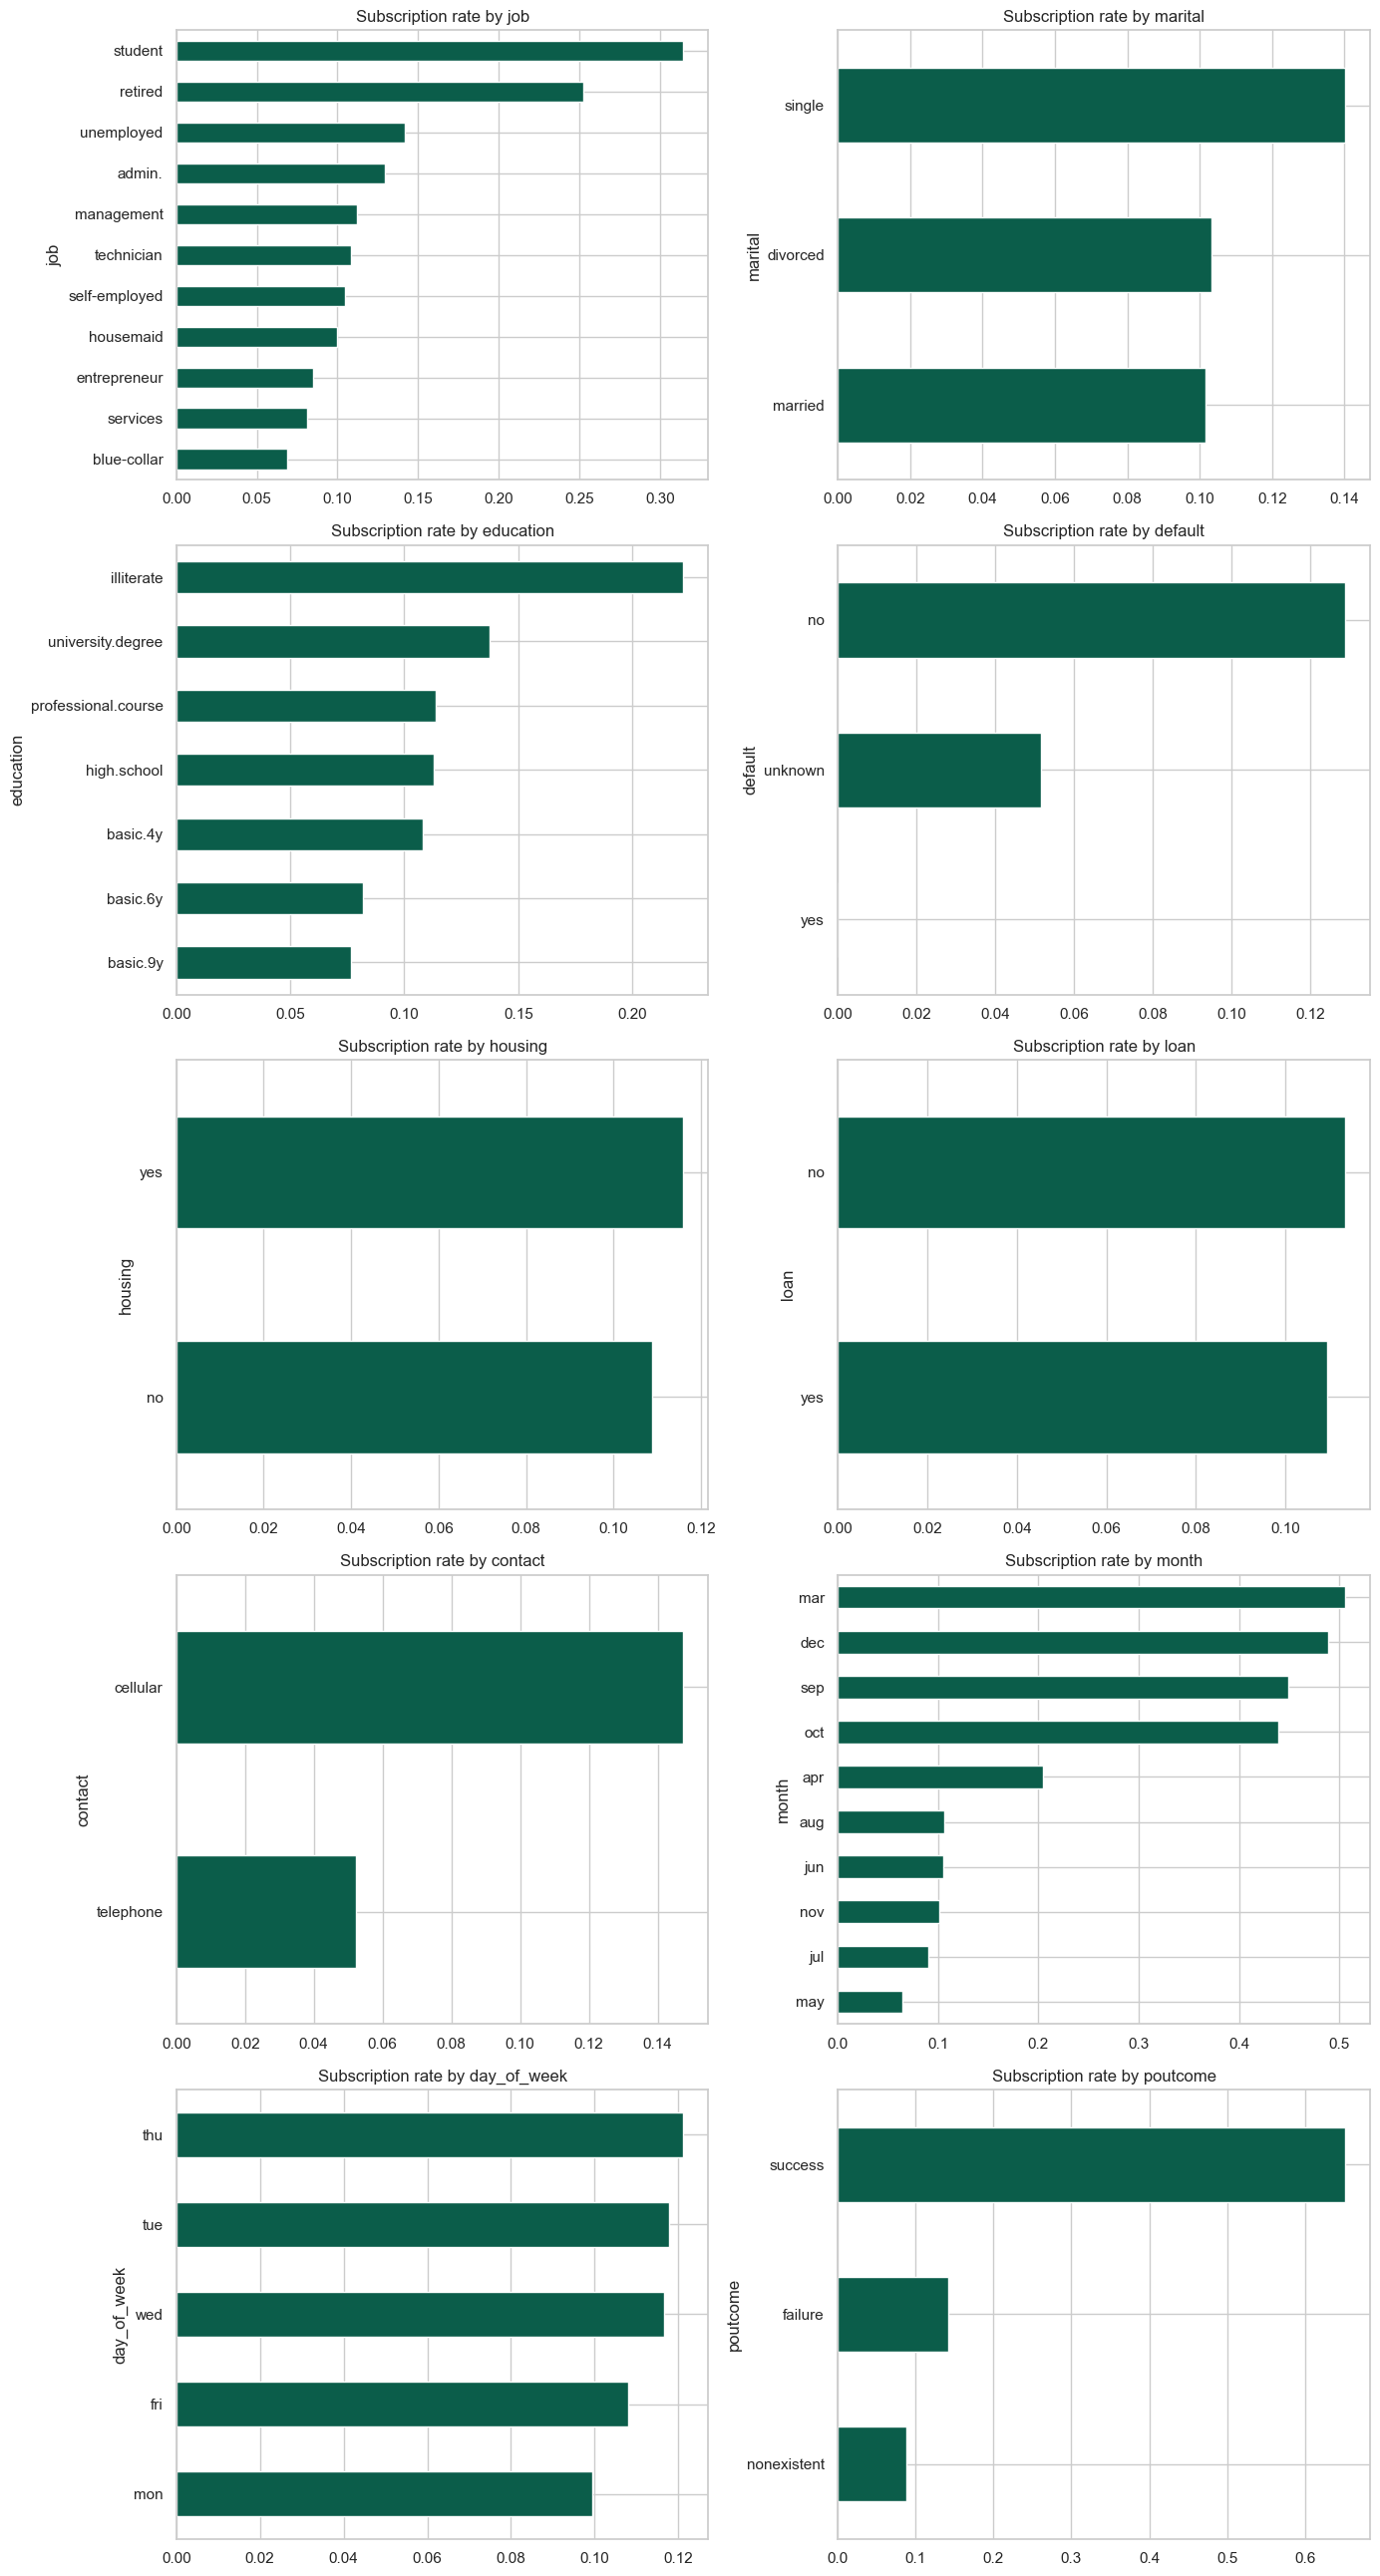

In [22]:
# Check Categorical features split by target 

cat_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 26))

for ax, col in zip(axes.flatten(), cat_cols):
    rate = (
        df.groupby(col)['y']
        .apply(lambda s: (s == 'yes').mean())
        .sort_values()
    )
    rate.plot(kind='barh', ax=ax, color='#0b5d4a')
    ax.set_title(f"Subscription rate by {col}")

plt.tight_layout()
plt.savefig("../reports/categorical_rates.png", dpi=150)
plt.show()

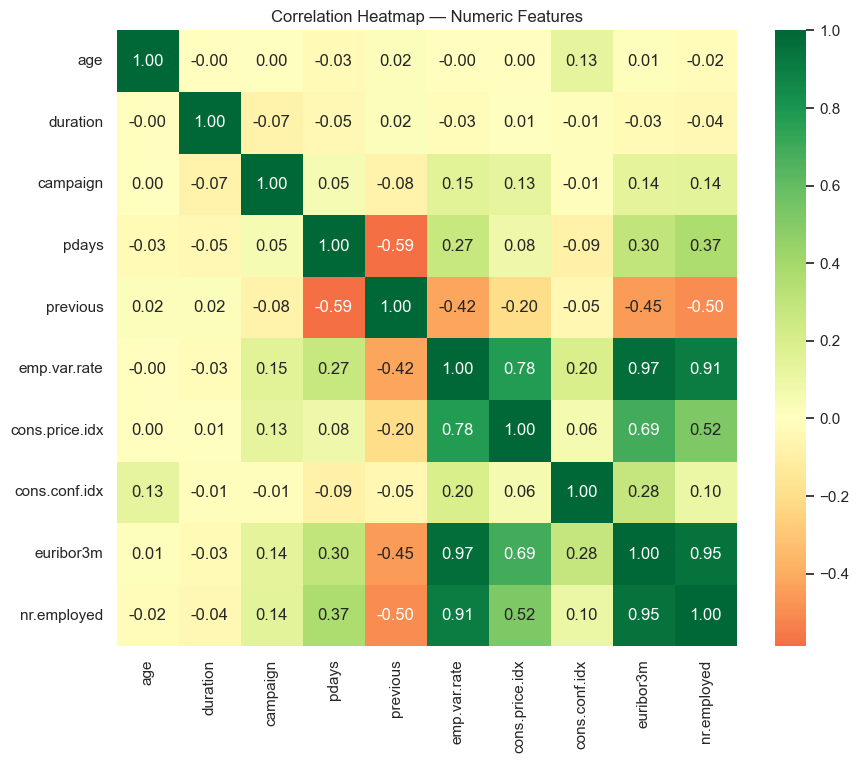

In [23]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("Correlation Heatmap — Numeric Features")
plt.savefig("../reports/correlation_heatmap.png", dpi=150)
plt.show()

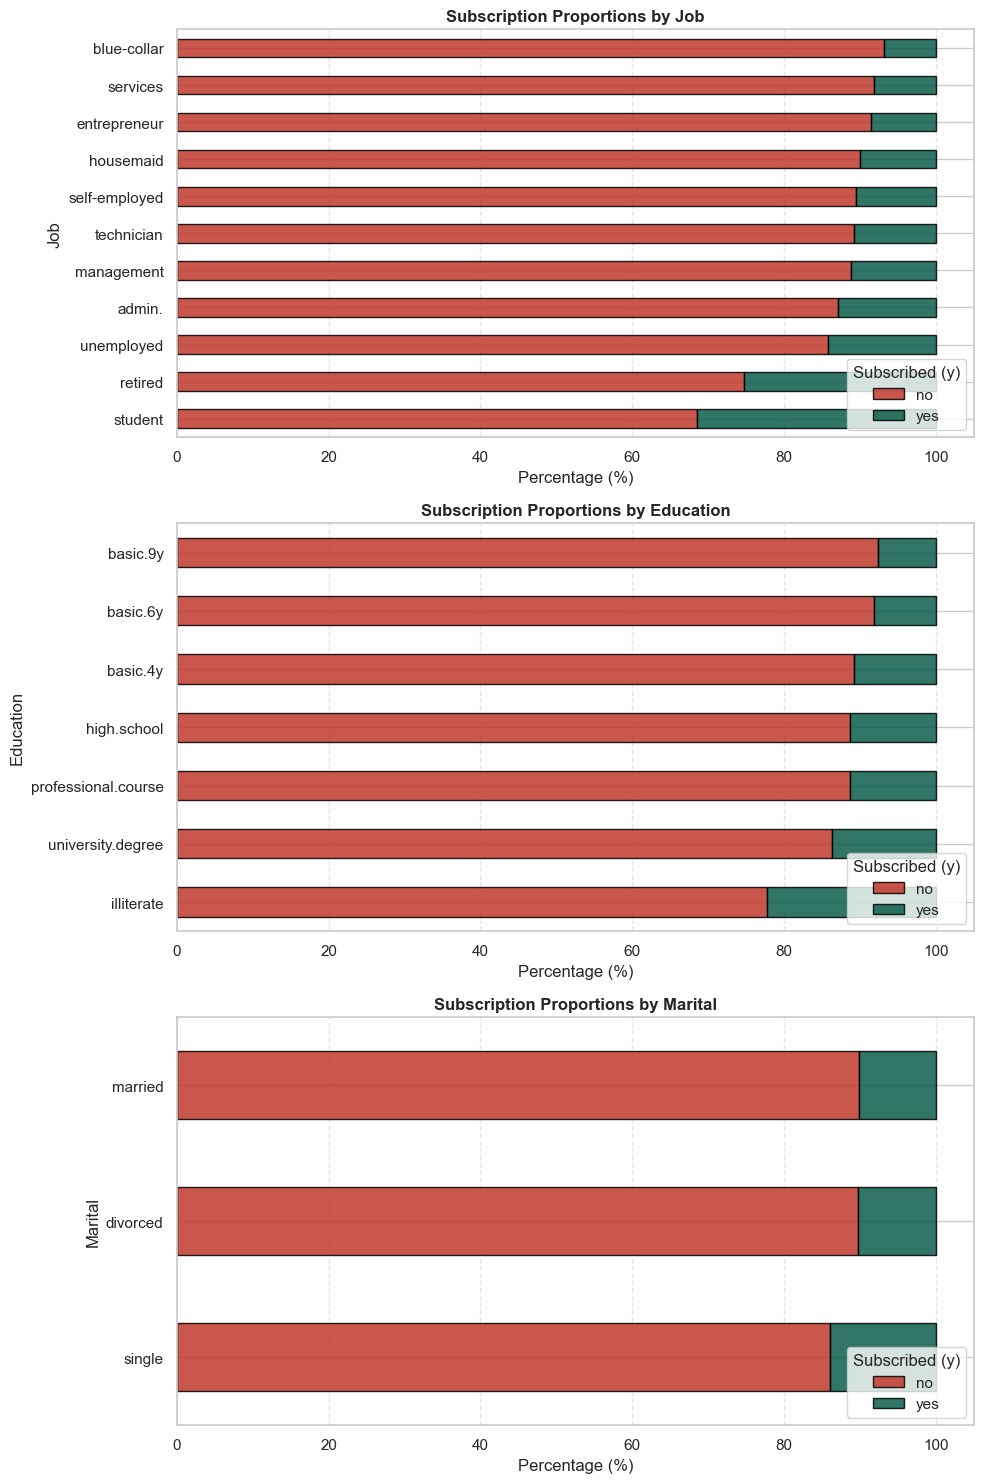

In [24]:
#target variable distribution
demo_features = ['job', 'education', 'marital']

# Set up the matplotlib figure grid
fig, axes = plt.subplots(len(demo_features), 1, figsize=(10, 5 * len(demo_features)))

for i, col in enumerate(demo_features):
    # 1. Create a cross-tabulation and normalize by row (index)
    crosstab = pd.crosstab(df[col], df['y'], normalize='index') * 100
    
    # 2. Sort the categories by the success rate ('yes') so the chart is easy to read
    crosstab = crosstab.sort_values(by='yes', ascending=False)
    
    # 3. Plot the normalized stacked horizontal bar chart
    crosstab.plot(
        kind='barh', 
        stacked=True, 
        ax=axes[i], 
        color=['#c0392b', '#0b5d4a'], # Keeping your color palette cohesive
        edgecolor='black',
        alpha=0.85
    )
    
    # Aesthetics
    axes[i].set_title(f"Subscription Proportions by {col.capitalize()}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel(col.capitalize())
    axes[i].legend(title="Subscribed (y)", loc='lower right')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../reports/demographic_proportions.png", dpi=150)
plt.show()

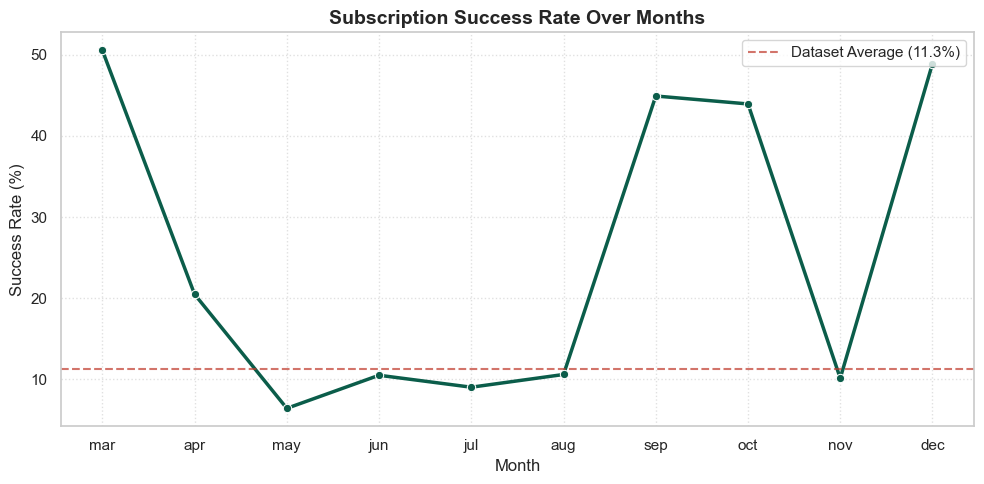

In [25]:
#subscription rate over month
# Define correct calendar order for months
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun','jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Calculate the subscription rate per month
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})
monthly_rates = df.groupby('month')['y_binary'].mean().reset_index()

# Convert month column to a categorical type with the specified order
monthly_rates['month'] = pd.Categorical(monthly_rates['month'], categories=month_order, ordered=True)
monthly_rates = monthly_rates.sort_values('month')

# Convert proportions to percentages for easier reading
monthly_rates['subscription_rate_%'] = monthly_rates['y_binary'] * 100

# 3Plotting
plt.figure(figsize=(10, 5))
sns.lineplot(
    x='month', 
    y='subscription_rate_%', 
    data=monthly_rates, 
    marker='o',         # Adds visible points on each month
    linewidth=2.5, 
    color='#0b5d4a'     # Matching your existing green palette
)

# Highlight the average dataset baseline line (~11.2%)
baseline = df['y_binary'].mean() * 100
plt.axhline(baseline, color='#c0392b', linestyle='--', alpha=0.7, label=f'Dataset Average ({baseline:.1f}%)')

# Aesthetics
plt.title("Subscription Success Rate Over Months", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Clean up temporary column from dataframe
df.drop(columns=['y_binary'], inplace=True)

plt.tight_layout()
#plt.savefig("../reports/monthly_subscription_rates.png", dpi=150)
plt.show()